In [1]:
# ==================================================
# Student Productivity Analytics Project
# Exploratory Data Analysis (EDA)
# ==================================================

# Goal:
# Explore behavioral patterns, productivity trends,
# wellness relationships, and academic insights.

In [24]:
import os
print(os.listdir("/content/drive/MyDrive/student-productivity-analytics"))

['data', 'visuals', 'reports', 'dashboard', 'app', 'models', 'notebooks']


In [2]:
# ==================================================
# Import Libraries
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# ==================================================
# Visualization Settings
# ==================================================

plt.figure(figsize=(10, 6))

sns.set_style("whitegrid")

print("Visualization Settings Applied!")

Visualization Settings Applied!


<Figure size 1000x600 with 0 Axes>

In [4]:
# ==================================================
# Connect Google Drive
# ==================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ==================================================
# Project Paths
# ==================================================

PROJECT_PATH = "/content/drive/MyDrive/student-productivity-analytics"

CLEANED_DATA_PATH = f"{PROJECT_PATH}/data/cleaned"

VISUALS_PATH = f"{PROJECT_PATH}/visuals"

os.makedirs(VISUALS_PATH, exist_ok=True)

In [6]:
# ==================================================
# Load Cleaned Dataset
# ==================================================

dataset_path = (
    f"{CLEANED_DATA_PATH}/"
    "student_productivity_cleaned.csv"
)

df = pd.read_csv(dataset_path)

print("Dataset Loaded!")

Dataset Loaded!


In [7]:
# ==================================================
# Preview Dataset
# ==================================================

df.head()
df.shape

(15000, 20)

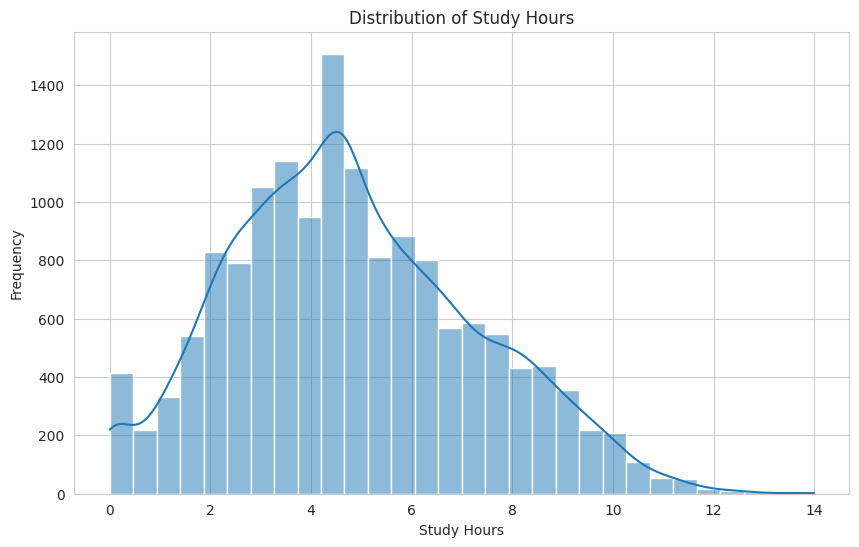

In [8]:
# ==================================================
# Distribution of Study Hours
# ==================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["Study_Hours"],
    bins=30,
    kde=True
)

plt.title("Distribution of Study Hours")

plt.xlabel("Study Hours")

plt.ylabel("Frequency")

plt.show()

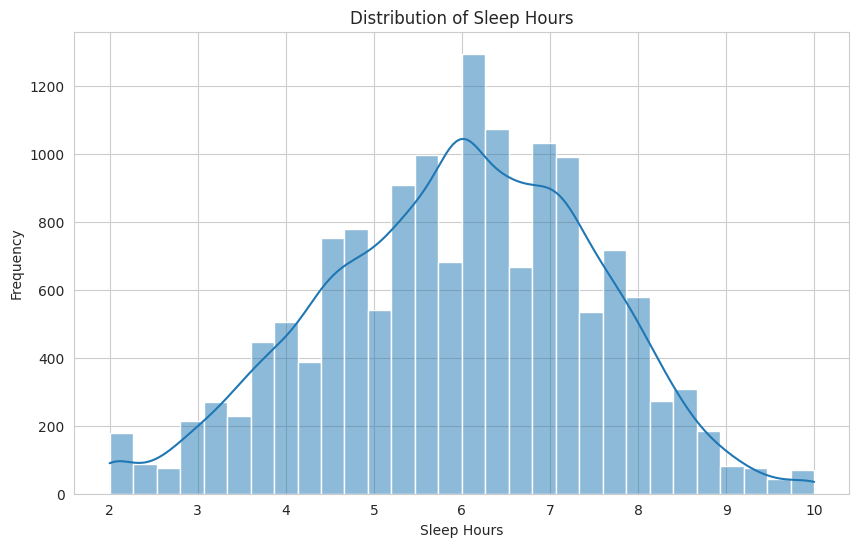

In [9]:
# ==================================================
# Sleep Hours Distribution
# ==================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["Sleep_Hours"],
    bins=30,
    kde=True
)

plt.title("Distribution of Sleep Hours")

plt.xlabel("Sleep Hours")

plt.ylabel("Frequency")

plt.show()

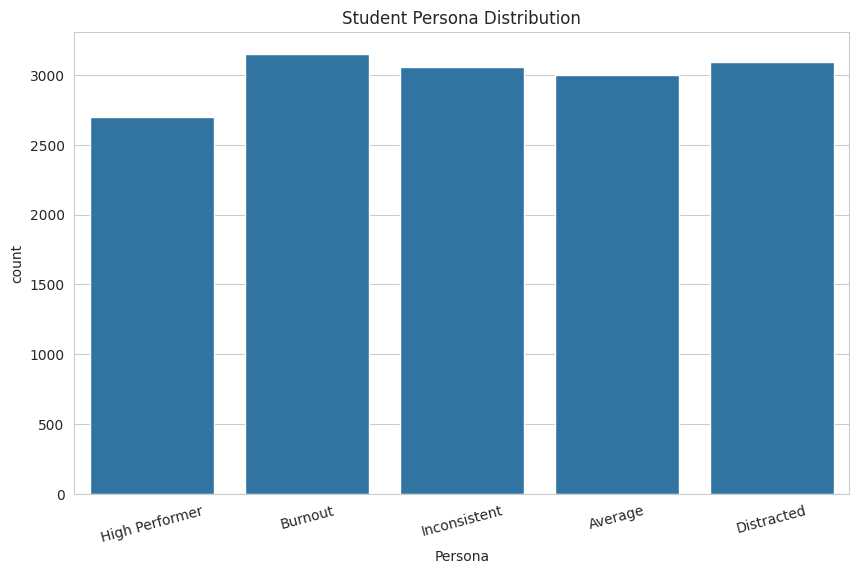

In [10]:
# ==================================================
# Persona Distribution
# ==================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Persona"
)

plt.title("Student Persona Distribution")

plt.xticks(rotation=15)

plt.show()

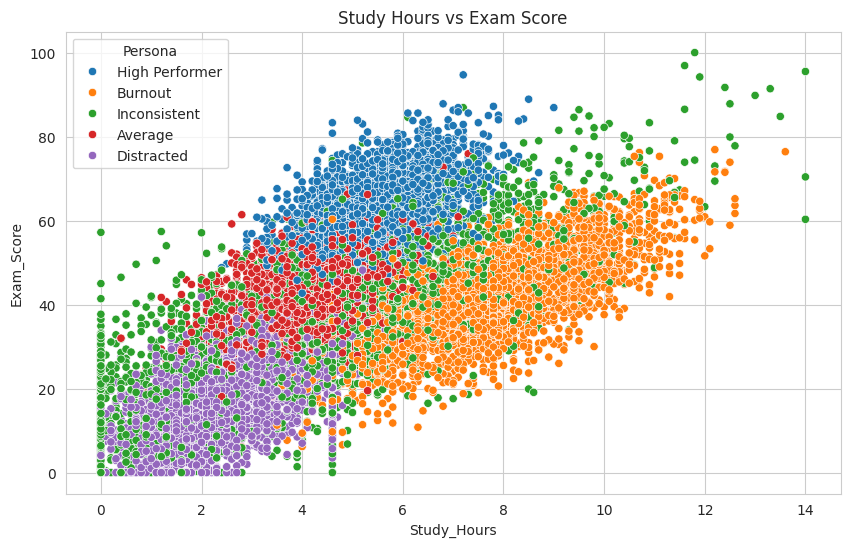

In [11]:
# ==================================================
# Study Hours vs Exam Score
# ==================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Exam_Score",
    hue="Persona"
)

plt.title("Study Hours vs Exam Score")

plt.show()

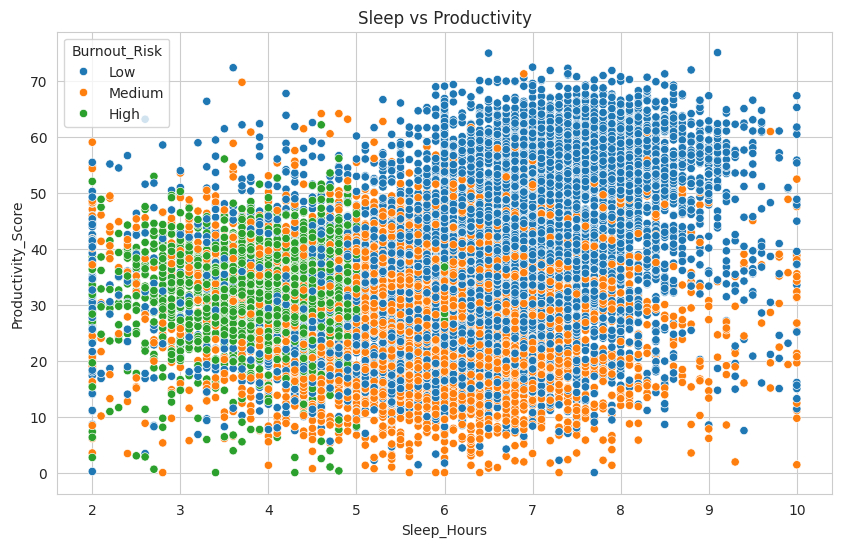

In [12]:
# ==================================================
# Sleep vs Productivity
# ==================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Sleep_Hours",
    y="Productivity_Score",
    hue="Burnout_Risk"
)

plt.title("Sleep vs Productivity")

plt.show()

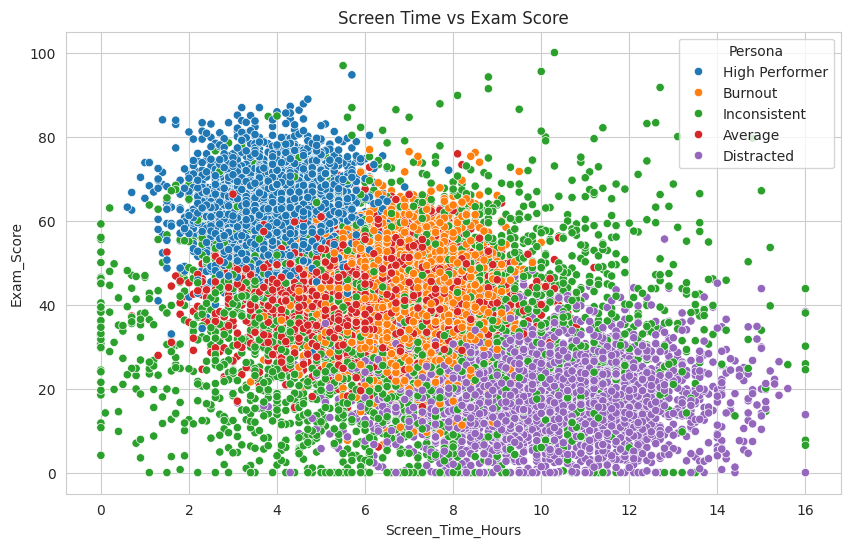

In [13]:
# ==================================================
# Screen Time vs Exam Score
# ==================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Screen_Time_Hours",
    y="Exam_Score",
    hue="Persona"
)

plt.title("Screen Time vs Exam Score")

plt.show()

In [15]:
# ==================================================
# Correlation Matrix
# ==================================================

numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

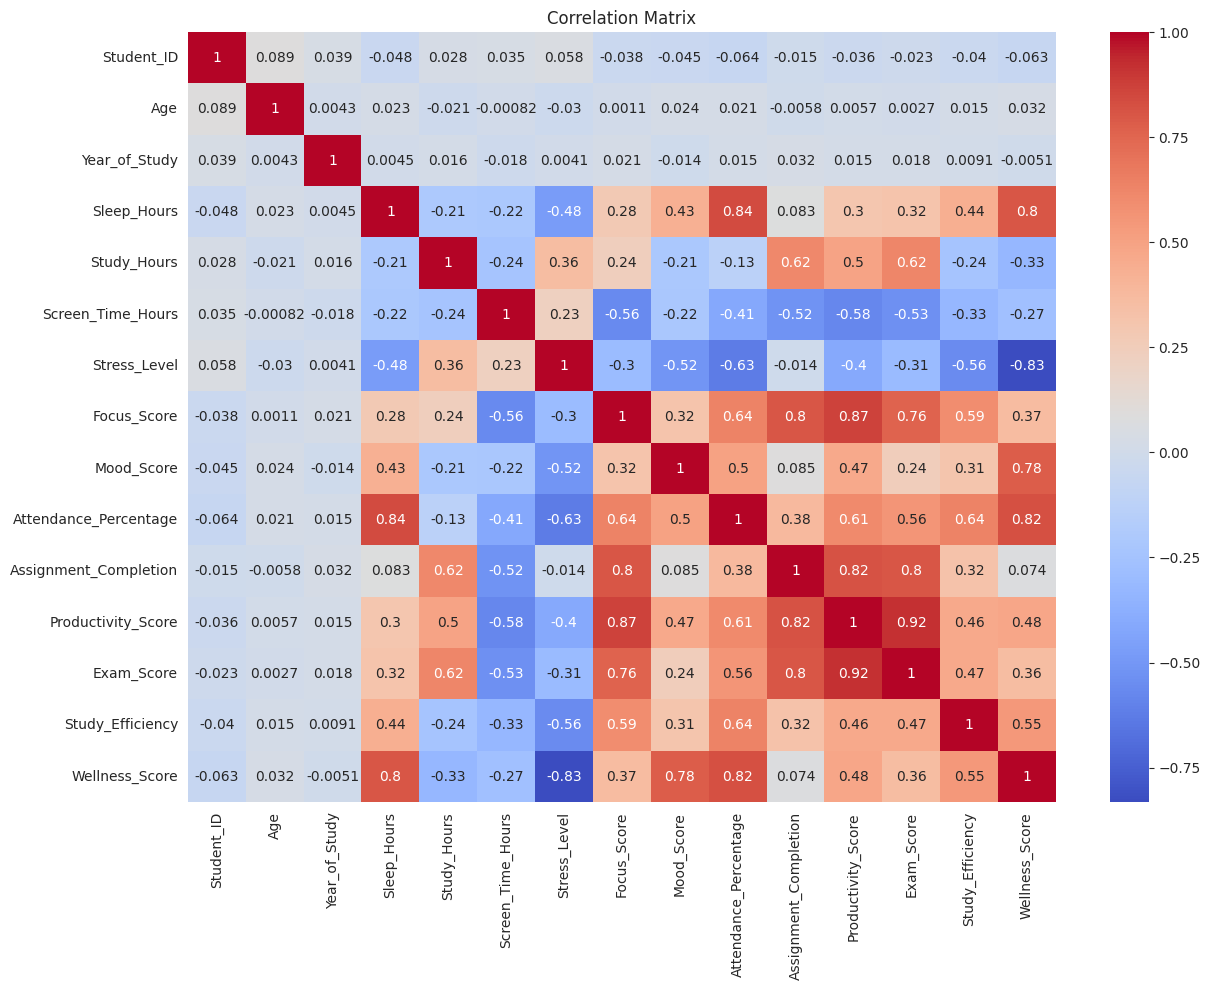

In [16]:
# ==================================================
# Correlation Heatmap
# ==================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

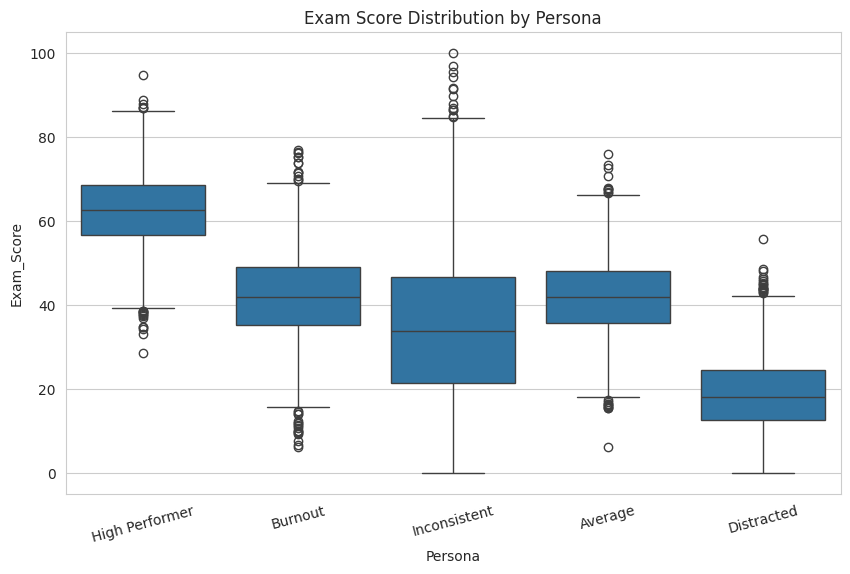

In [17]:
# ==================================================
# Persona vs Exam Score
# ==================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Persona",
    y="Exam_Score"
)

plt.title("Exam Score Distribution by Persona")

plt.xticks(rotation=15)

plt.show()

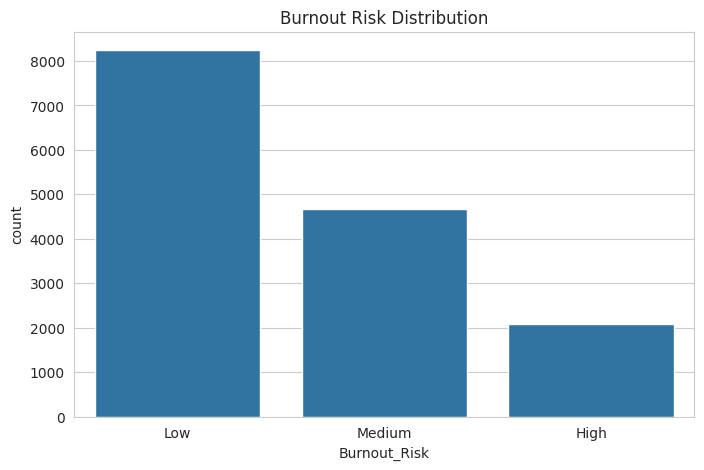

In [18]:
# ==================================================
# Burnout Risk Distribution
# ==================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Burnout_Risk"
)

plt.title("Burnout Risk Distribution")

plt.show()

In [19]:
# ==================================================
# Average Metrics by Persona
# ==================================================

persona_summary = df.groupby("Persona")[[
    "Study_Hours",
    "Sleep_Hours",
    "Exam_Score",
    "Stress_Level",
    "Productivity_Score"
]].mean()

persona_summary

,Study_Hours,Sleep_Hours,Exam_Score,Stress_Level,Productivity_Score
Persona,,,,,
Average,4.008500,6.497400,41.884867,5.009067,37.987500
Burnout,7.926286,4.532190,42.095270,8.939587,34.215714
Distracted,2.546796,6.005405,18.464304,5.970680,19.636181
High Performer,5.495222,7.477333,62.506370,4.019519,56.451481
Inconsistent,4.190294,5.505327,34.455882,5.977908,31.087843


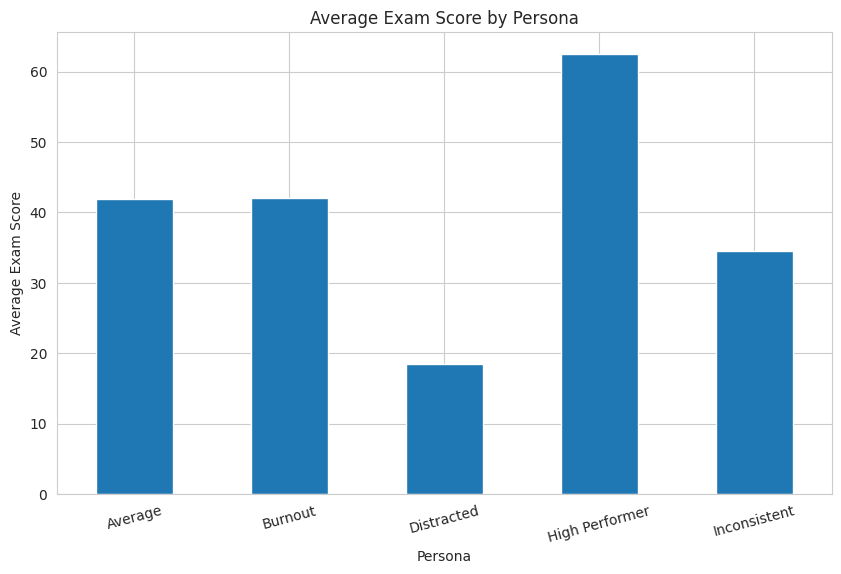

In [20]:
# ==================================================
# Persona Performance Visualization
# ==================================================

persona_summary["Exam_Score"].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Exam Score by Persona")

plt.ylabel("Average Exam Score")

plt.xticks(rotation=15)

plt.show()

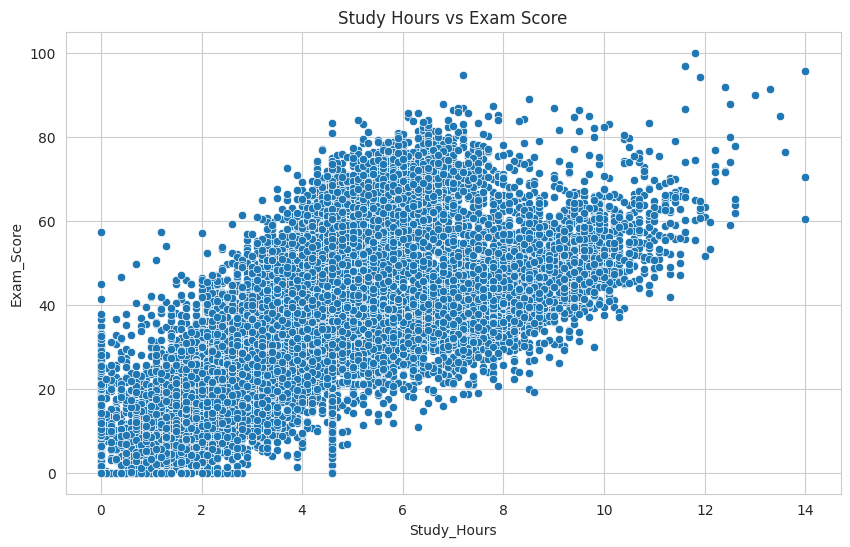

In [21]:
# ==================================================
# Save Visualization
# ==================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Exam_Score"
)

plt.title("Study Hours vs Exam Score")

visual_path = (
    f"{VISUALS_PATH}/study_vs_exam.png"
)

plt.savefig(visual_path)

plt.show()

In [22]:
# ==================================================
# Key Insights
# ==================================================

print("Key EDA Insights:")

print("- High performers show better sleep and focus.")

print("- Burnout students study more but perform less efficiently.")

print("- Higher stress levels correlate with lower productivity.")

print("- Excessive screen time negatively impacts performance.")

print("- Consistent students outperform inconsistent students.")

Key EDA Insights:
- High performers show better sleep and focus.
- Burnout students study more but perform less efficiently.
- Higher stress levels correlate with lower productivity.
- Excessive screen time negatively impacts performance.
- Consistent students outperform inconsistent students.


In [23]:
# ==================================================
# Verify Visual Files
# ==================================================

os.listdir(VISUALS_PATH)

['study_vs_exam.png']